# Rank Histograms with Real Data

This notebook computes rank histograms for 850hPa wind speed ensemble forecasts from the ECMWF IFS ensemble and Neural GCM, verified against ERA5 reanalysis. Data is from [WeatherBench2](https://weatherbench2.readthedocs.io/) on a 1.5° grid.

In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scores.probability import rank_histogram
from scores.functions import create_latitude_weights
from scores.processing import broadcast_and_match_nan

## Load data from WeatherBench2

In [2]:
ifs_ens = xr.open_zarr(
    "gs://weatherbench2/datasets/ifs_ens/2018-2022-240x121_equiangular_with_poles_conservative.zarr",
    decode_timedelta=True,
)
neural_gcm = xr.open_zarr(
    "gs://weatherbench2/datasets/neuralgcm_ens/2020-240x121_equiangular_with_poles_conservative.zarr",
    decode_timedelta=True,
)
era5 = xr.open_zarr(
    "gs://weatherbench2/datasets/era5/1959-2023_01_10-6h-240x121_equiangular_with_poles_conservative.zarr",
    decode_timedelta=True,
)

## Select and prepare 850hPa wind speed data

We select one week of forecasts at a 2-day lead time and the corresponding ERA5 valid times.

Note the following cell may take several minutes to retrieve the data

In [11]:
lead_time = pd.Timedelta("2d")

ifs_ens_wind = ifs_ens.wind_speed.sel(
    level=850, time=slice("2020-03-01T00:00:00", "2020-03-07T00:00:00"), prediction_timedelta=lead_time
).compute()
neural_gcm_wind = neural_gcm.wind_speed.sel(
    level=850, time=slice("2020-03-01T00:00:00", "2020-03-07T00:00:00"), prediction_timedelta=lead_time
).compute()

# Note, since we are looking at lead day 2 forecasts, we add 2 days to the obs
era5_wind = era5.wind_speed.sel(
    level=850, time=slice("2020-03-03T00:00:00", "2020-03-09T00:00:00")
).compute()

In [6]:
# Align forecast time coordinates to valid (observation) times
ifs_ens_wind = ifs_ens_wind.assign_coords({"time": ifs_ens_wind.time + lead_time})
neural_gcm_wind = neural_gcm_wind.assign_coords({"time": neural_gcm_wind.time + lead_time})

# Rename Neural GCM ensemble dim to match IFS
neural_gcm_wind = neural_gcm_wind.rename({"realization": "number"})

# Align missing data between the two forecast systems
ifs_ens_wind, neural_gcm_wind = broadcast_and_match_nan(ifs_ens_wind, neural_gcm_wind)

## Compute rank histograms

In [7]:
rank_hist_ifs = rank_histogram(ifs_ens_wind, era5_wind, "number", reduce_dims="all")
rank_hist_ngcm = rank_histogram(neural_gcm_wind, era5_wind, "number", reduce_dims="all")

## Plot rank histograms

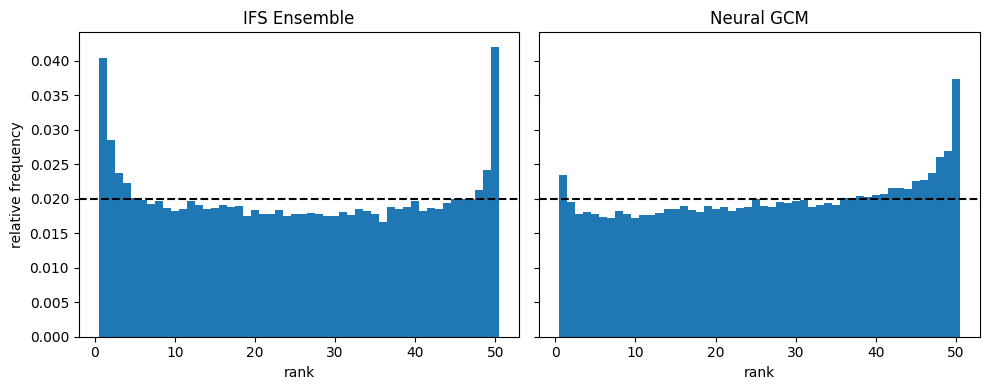

In [9]:
n_ifs_members = len(ifs_ens_wind.number)
n_ngcm_members = len(neural_gcm_wind.number)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(rank_hist_ifs["rank"].values, rank_hist_ifs.values, width=1)
axes[0].axhline(y=1 / (n_ifs_members + 1), color="k", linestyle="--")
axes[0].set_title("IFS Ensemble")
axes[0].set_xlabel("rank")
axes[0].set_ylabel("relative frequency")

axes[1].bar(rank_hist_ngcm["rank"].values, rank_hist_ngcm.values, width=1)
axes[1].axhline(y=1 / (n_ngcm_members + 1), color="k", linestyle="--")
axes[1].set_title("Neural GCM")
axes[1].set_xlabel("rank")

plt.tight_layout()
plt.show()

## Weighted rank histograms (latitude weighting)

Latitude weights account for the varying area of grid cells. 

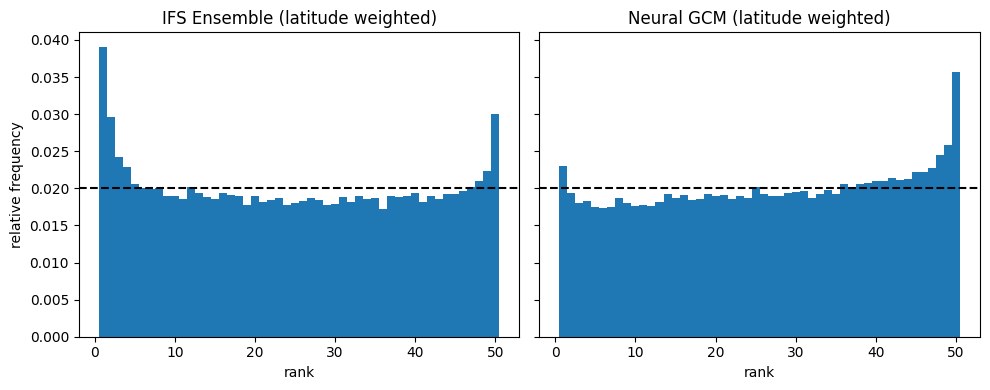

In [10]:
lat_weights = create_latitude_weights(ifs_ens_wind.latitude)

rank_hist_ifs_w = rank_histogram(ifs_ens_wind, era5_wind, "number", reduce_dims="all", weights=lat_weights)
rank_hist_ngcm_w = rank_histogram(neural_gcm_wind, era5_wind, "number", reduce_dims="all", weights=lat_weights)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

axes[0].bar(rank_hist_ifs_w["rank"].values, rank_hist_ifs_w.values, width=1)
axes[0].axhline(y=1 / (n_ifs_members + 1), color="k", linestyle="--")
axes[0].set_title("IFS Ensemble (latitude weighted)")
axes[0].set_xlabel("rank")
axes[0].set_ylabel("relative frequency")

axes[1].bar(rank_hist_ngcm_w["rank"].values, rank_hist_ngcm_w.values, width=1)
axes[1].axhline(y=1 / (n_ngcm_members + 1), color="k", linestyle="--")
axes[1].set_title("Neural GCM (latitude weighted)")
axes[1].set_xlabel("rank")

plt.tight_layout()
plt.show()